# Optimal Transport with Linear Programming [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xavimaass/computational_optimal_transport_2026/blob/main/assignments/HW1.ipynb)

In this assignment we will see how to solve the discrete optimal transport
problem (in the case of measures that are sums of Diracs) using linear
programming.

You need to install [CVXPY](https://www.cvxpy.org/). We recommend to run this in Google Colab, which has it pre-installed.

However, if running locally, you can simply do ```uv sync``` and it should install all the required dependencies (get to know [uv](https://docs.astral.sh/uv/)).

In [24]:
pip install cvxpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

Optimal Transport of Discrete Distributions
------------------------------------------

We consider two discrete distributions
$$
\alpha = \sum_{i=1}^n a_i \delta_{x_i} \quad \text{and} \quad
\beta = \sum_{j=1}^m b_j \delta_{y_j}.
$$

where $n, m$ are the number of points, $\delta_x$ is the Dirac at
location $x \in \mathbb{R}^d$, and $(x_i)_i$, $(y_j)_j$ are the positions of the Diracs in $\mathbb{R}^d$.

Consider the dimensions $n = 60$, $m=80$ for the coulds.

In [26]:
n = 60
m = 80

**Exercise 1.** Generate the point clouds $X=(x_i)_{i=1}^n$ and $Y=(y_j)_{j=1}^m$ as follows:
- Each point $x_i$, $y_i$ will be in $\mathbb{R}^2$
- Each $x_i$ must be i.i.d. sampled from a Gaussian random variable $N([0,0], \sigma^2 Id_2)$ with $\sigma = 0.3$
- Each $y_i$ must be sampled from a **mixture of gaussians** as follows:
  - Half of the points must be i.i.d. gaussians centered at [0, 1.6] with std $0.5$.
  - One quarter of the points must be i.i.d. gaussians centered at [-1, -1] with std $0.3$.
  - One quarter of the points must be i.i.d. gaussians centered at [1, 1] with std $0.3$.

In [27]:
# FILL IN WITH YOUR ANSWER
sigma_1=0.3
sigma_2=0.5
mu_1=[0, 0]
mu_2=[0,1.6]
mu_3=[-1,-1]
mu_4=[1,1]
cov_1 = np.array([[sigma_1**2, 0], [0,sigma_1**2]])
cov_2 = np.array([[sigma_2**2, 0], [0,sigma_2**2]])
X = np.transpose(np.random.multivariate_normal(mu_1, cov_1, size=n))
Y1=np.transpose(np.random.multivariate_normal(mu_2, cov_2, size= int(m/2)))
Y2=np.transpose(np.random.multivariate_normal(mu_3, cov_2, size= int(m/4)))
Y3=np.transpose(np.random.multivariate_normal(mu_4, cov_1, size=int(m/4)))
Y = np.hstack([Y1, Y2, Y3])

# X should be an array of shape (2, n) and Y should be an array of shape (2, m)

**Exercise 2.** Generate random weights $a,b$ for our discrete distributions. For this, simply normalize (to get a probability distribution) a sample of standard gaussians in $\mathbb{R}^n$ and $\mathbb{R}^m$, respectively.

In [28]:
# FILL IN WITH YOUR ANSWER

a = np.abs(np.random.randn(n))
a /= a.sum()

b = np.abs(np.random.randn(m))
b /= b.sum()

# a should be an array of shape (n,) and b should be an array of shape (m,)

We give you the following helper function for displaying point clouds.

In [29]:
myplot = lambda x,y,ms,col: plt.scatter(x,y, s=ms*20, edgecolors="k", c=col, linewidths=2)

Use the following code to display the point clouds. The size of each dot is proportional to its probability density weight.

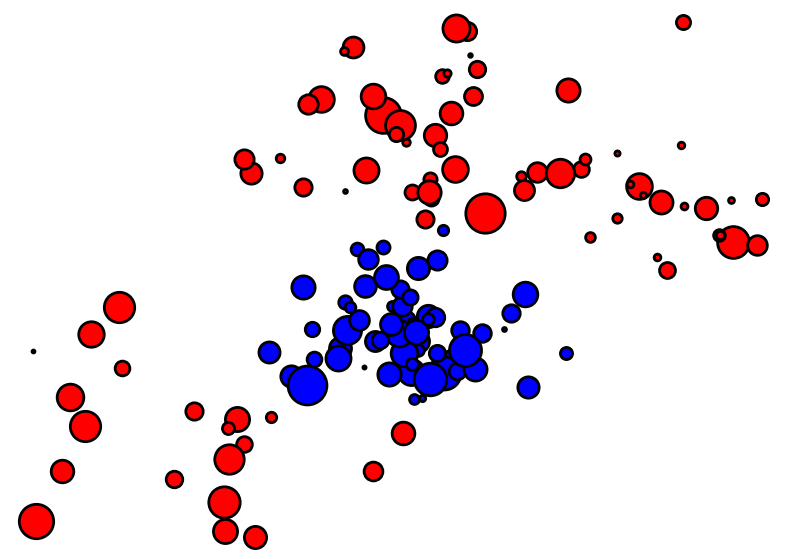

In [30]:
plt.figure(figsize = (10,7))
plt.axis("off")
for i in range(len(a)):
    myplot(X[0,i], X[1,i], a[i]*len(a)*10, 'b')
for j in range(len(b)):
    myplot(Y[0,j], Y[1,j], b[j]*len(b)*10, 'r')
plt.xlim(np.min(Y[0,:])-.1,np.max(Y[0,:])+.1)
plt.ylim(np.min(Y[1,:])-.1,np.max(Y[1,:])+.1)
plt.show()

**Exercise 3.** Describe the point cloud. How is $\alpha$ different from $\beta$ ?

The blue points are closer to each others compared to the red ones.

**Exercise 4.** Compute the cost matrix $C_{i,j} := \|x_i-x_j\|^2$.

In [44]:
def distmat(x, y):
    """Compute squared Euclidean distance matrix C where C[i,j] = ||x_i - y_j||^2
    Parameters:
        x: array of shape (2, n) containing source points
        y: array of shape (2, m) containing target points
    Returns:
        C: array of shape (n, m) containing squared distances
    """
    # FILL IN
    C = np.zeros((n, m))

    for i in range(n):
        for j in range(m):
            diff = x[:, i] - y[:, j]
            C[i, j] = np.sum(diff**2)
    return C

In [45]:
C = distmat(X,Y)

We will use `cvxpy` for solving this linear program. See some documentation [here](https://www.cvxpy.org/).

**Exercise 5.** Solve the linear program using`cvxpy`.

For this, know that `cvxpy` works by having you declare three things: a variable, a list of constraints, and an objective. You then wrap them into a cp.Problem and call .solve().

**a) Variable.** Declare a matrix-valued optimization variable $P \in \mathbb{R}^{n \times m}$ using `cp.Variable((n, m))`.

In [46]:
P = cp.Variable((n,m))

**b) Constraints.** We know that the set of discrete couplings between $\alpha$ and $\beta$ is
$$
U(a, b) := \left\{ P \in \mathbb{R}_+^{n \times m} \;\middle|\;
\forall i, \sum_j P_{i,j} = a_i, \quad
\forall j, \sum_i P_{i,j} = b_j \right\}.
$$
Encode this as a Python list `constraints` that allow to define the domain. Note that `cp.sum(P, axis=1, keepdims=True)` computes row sums, `cp.sum(P, axis=0, keepdims=True).T` computes column sums and `P>=0` defines positivity.

In [47]:

constraints = [
    P >= 0,
    cp.sum(P, axis=1, keepdims=True) == a.reshape((n, 1)),
    cp.sum(P, axis=0, keepdims=True).T == b.reshape((m, 1))

]

**c) Objective.** We know that the Kantorovich formulation of optimal transport reads
$$
    P^\star \in \underset{P \in U(a, b)}{\arg\min} \sum_{i,j} P_{i,j} C_{i,j}.
$$

Write down this objective function by using:
- `cp.multiply` for elementwise multiplication
- `cp.sum` to sum all entries.
- Define the objective function as `objective = cp.Minimize(...the sum of elementwise products...)`.

In [48]:
objective = cp.Minimize(cp.sum(cp.multiply(P, C)))

**d) Solve**. Combine the objective and constraints into an object `prob = cp.Problem(objective, constraints)` and call .solve() to recover the optimal value.

In [49]:
prob = cp.Problem(objective, constraints)
try:
    result = prob.solve(solver=cp.SCS, verbose=True)
except Exception as e:
    print("SCS failed:", e)

(CVXPY) Apr 22 11:01:03 AM: Your problem has 4800 variables, 4940 constraints, and 0 parameters.
(CVXPY) Apr 22 11:01:03 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 22 11:01:03 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 22 11:01:03 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 22 11:01:03 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 22 11:01:03 AM: Compiling problem (target solver=SCS).
(CVXPY) Apr 22 11:01:03 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 22 11:01:03 AM: Applying reduction Dcp2Cone
(CVXPY) Apr 22 11:01:03 AM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 22 11:01:03 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 22 11:01:03 AM: Applying reduction SCS
(CVXPY) Apr 22 11:01:03 AM: Finished problem compilation (took 2

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 4800, constraints m: 4940
cones: 	  z: primal zero / dual free vars: 140
	  l: linear vars: 4800
settings: 

(CVXPY) Apr 22 11:01:03 AM: Problem status: optimal
(CVXPY) Apr 22 11:01:03 AM: Optimal value: 1.862e+00
(CVXPY) Apr 22 11:01:03 AM: Compilation took 2.381e-02 seconds
(CVXPY) Apr 22 11:01:03 AM: Solver (including time spent in interface) took 5.161e-01 seconds


  2750| 2.21e-07  4.68e-04  3.13e-05  1.86e+00  4.76e+02  4.37e-01 
  3000| 1.62e-07  4.78e-04  2.55e-05  1.86e+00  4.76e+02  4.76e-01 
  3250| 5.25e-08  1.25e-04  6.36e-06  1.86e+00  4.76e+02  5.15e-01 
------------------------------------------------------------------
status:  solved
timings: total: 5.15e-01s = setup: 8.77e-03s + solve: 5.07e-01s
	 lin-sys: 3.91e-01s, cones: 3.69e-02s, accel: 1.24e-02s
------------------------------------------------------------------
objective = 1.862473
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


An optimal coupling $P^\star$ can be shown to be a sparse matrix
with less than $n+m-1$ non zero entries. An entry $P_{i,j}^\star \neq 0$
should be understood as a link between $x_{i}$
and $y_{j}$ where an amount of mass equal to $P_{i,j}^\star$ is transfered.

**Exercise 6.** Check that the number of non-zero entries in $P^\star$ is $n+m-1$. Beware that we are using an interior point method here, so that entries of $P^\star$ are nevery exactly 0.

In [50]:
tol = 1e-8
nnz = np.sum(np.abs(P.value) > tol)
print(nnz, n + m - 1)

2335 139


We now visualize the solution coupling.

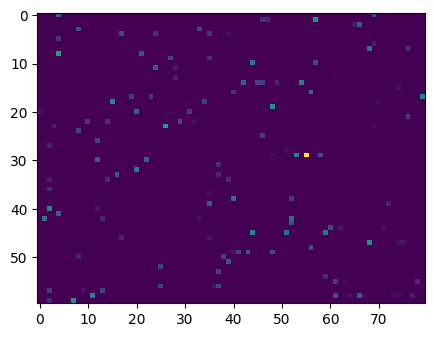

In [51]:
plt.figure(figsize = (5,5))
plt.imshow(P.value);

We also display the connexion defined by the optimal coupling.

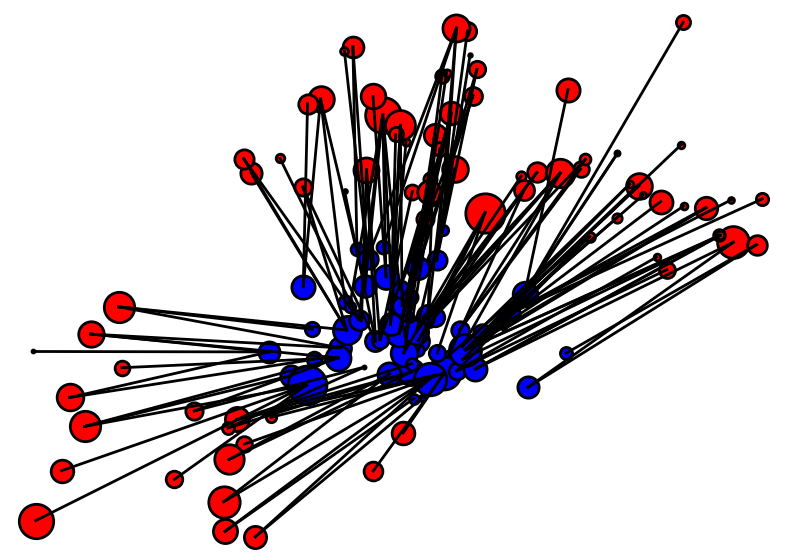

In [52]:
I,J = np.nonzero(P.value>1e-5)
plt.figure(figsize = (10,7))
plt.axis('off')
for k in range(len(I)):
    h = plt.plot(np.hstack((X[0,I[k]],Y[0,J[k]])),np.hstack(([X[1,I[k]], Y[1,J[k]]])),'k', lw = 2)
for i in range(len(a)):
    myplot(X[0,i], X[1,i], a[i]*len(a)*10, 'b')
for j in range(len(b)):
    myplot(Y[0,j], Y[1,j], b[j]*len(b)*10, 'r')
plt.xlim(np.min(Y[0,:])-.1,np.max(Y[0,:])+.1)
plt.ylim(np.min(Y[1,:])-.1,np.max(Y[1,:])+.1)
plt.show()

**Exercise 7.** What do you see? Is this coupling defined by a transport map?

The plot shows the blue source points ($\alpha$) tightly clustered near the origin, with black lines radiating outward to the red target points ($\beta$) which are spread across three distant clusters. Most notably, **many lines originate from the same blue point**, fanning out toward different red targets — meaning a single source particle is splitting its mass across multiple destinations.

**This coupling is not defined by a transport map.** A transport map would require each red dot to be sent to a blue one without splitting it to more than one.

Displacement Interpolation
--------------------------
**[NO exercises on this section]**

For any $t \in [0,1]$, one can define a distribution $\mu_t$ such that the map $t \mapsto \mu_t$ describes a geodesic in the Wasserstein space.

Since the $W_2$ distance is a geodesic distance, this geodesic path solves the following variational problem:
$$
\mu_t = \underset{\mu}{\arg\min} \, (1 - t) W_2(\alpha, \mu)^2 + t W_2(\beta, \mu)^2.
$$

This can be understood as a generalization of the classical Euclidean barycenter to the barycenter of probability distributions. Indeed, in the special case where $\alpha = \delta_x$ and $\beta = \delta_y$, one obtains $\mu_t = \delta_{x_t}$ with
$$
x_t = (1 - t)x + t y.
$$

Once the optimal coupling $P^\star$ has been computed, the interpolated distribution is given by
$$
\mu_t = \sum_{i,j} P^\star_{i,j} \, \delta_{(1 - t)x_i + t y_j}.
$$

We can visualize this by finding the $i,j$ with non-zero $P_{i,j}^\star$.

In [53]:
I,J = np.nonzero(P.value>1e-5)
Pij = P.value[I,J]

And we now display the evolution of $\mu_t$ for a varying value of $t \in [0,1]$.

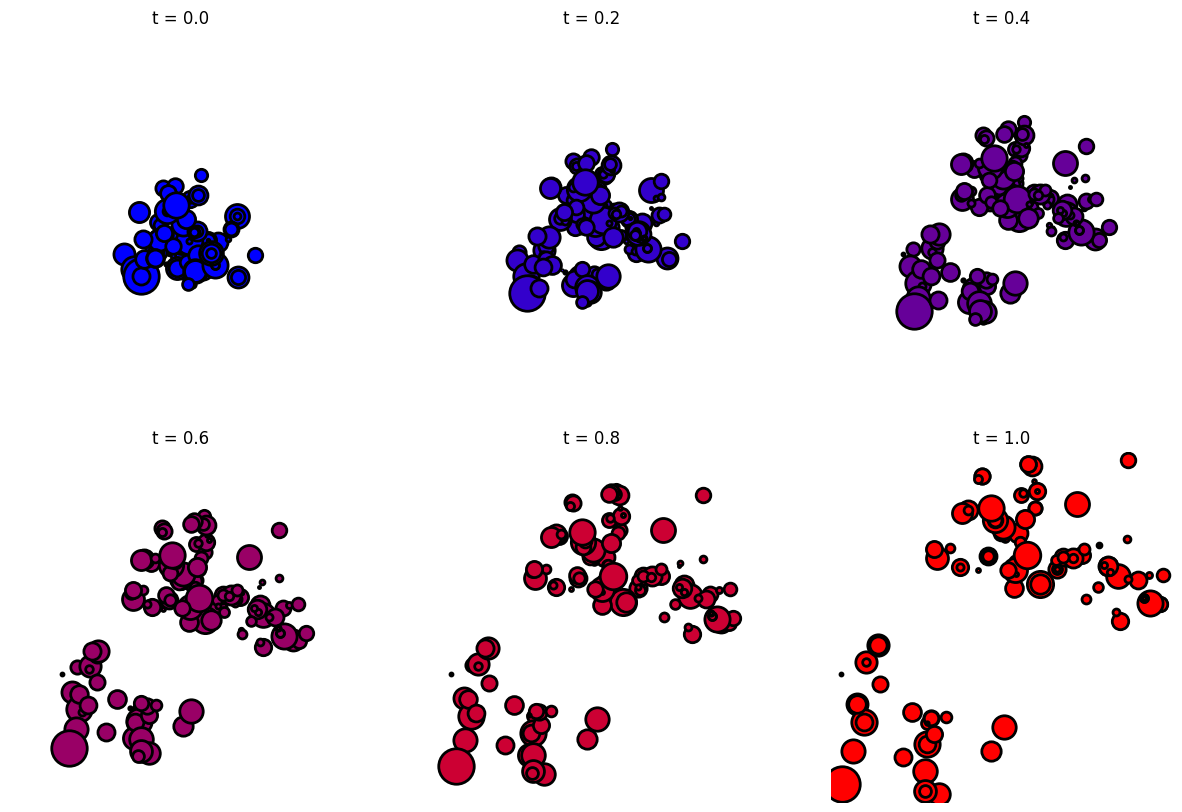

In [54]:
plt.figure(figsize =(15,10))
tlist = np.linspace(0, 1, 6)
for i in range(len(tlist)):
    t = tlist[i]
    Xt = (1-t)*X[:,I] + t*Y[:,J]
    plt.subplot(2,3,i+1)
    plt.axis("off")
    for j in range(len(Pij)):
        myplot(Xt[0,j],Xt[1,j],Pij[j]*len(Pij)*6,[[t,0,1-t]])
    plt.title("t = %.1f" %t)
    plt.xlim(np.min(Y[0,:])-.1,np.max(Y[0,:])+.1)
    plt.ylim(np.min(Y[1,:])-.1,np.max(Y[1,:])+.1)
plt.show()

Optimal Assignement
-------------------
In the case where $n = m$ and the weights are uniform, i.e., $a_i = 1/n$ and $b_j = 1/n$, one can show that there exists at least one optimal transport coupling that is a permutation matrix. This property arises from the fact that the extremal points of the transport polytope $U(1, 1)$ are permutation matrices.

This means there exists an optimal permutation $\sigma^\star \in \Sigma_n$ such that
$$
P^\star_{i,j} =
\begin{cases}
1 & \text{if } j = \sigma^\star(i), \\
0 & \text{otherwise}.
\end{cases}
$$

Here, $\Sigma_n$ denotes the set of all permutations (bijections) of $\{1, \ldots, n\}$.

This permutation solves the so-called *optimal assignment problem*:
$$
\sigma^\star \in \underset{\sigma \in \Sigma_n}{\arg\min}
\sum_{i=1}^n C_{i, \sigma(i)}.
$$

**Exercise 8.** Repeat all the previous steps to solve this problem. Namely:
- Set $n=40=m$.
- Compute the same point clouds as in **Ex.1**.
- Set **uniform** weights on the particles (**unlike Ex.2**, no randomness here).
- Compute the cost matrix (you can use the functions you built!).
- Solve the Optimal Transport problem using `cvxpy`.
- Visualize the optimal assignment, as in **Ex.7**
- Visualize the displacement interpolation, as in the previous section.

Comment on the obtained results and on the key differences with the case $n\neq m$.

Optimal transport cost: 1.8363
Non-zero entries (tol=1e-05): 40  |  n+m-1 = 79  |  n = 40


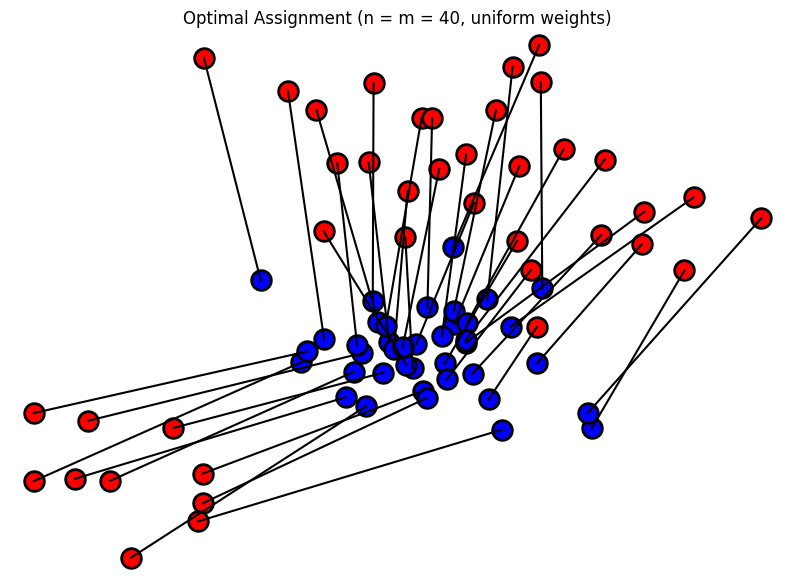

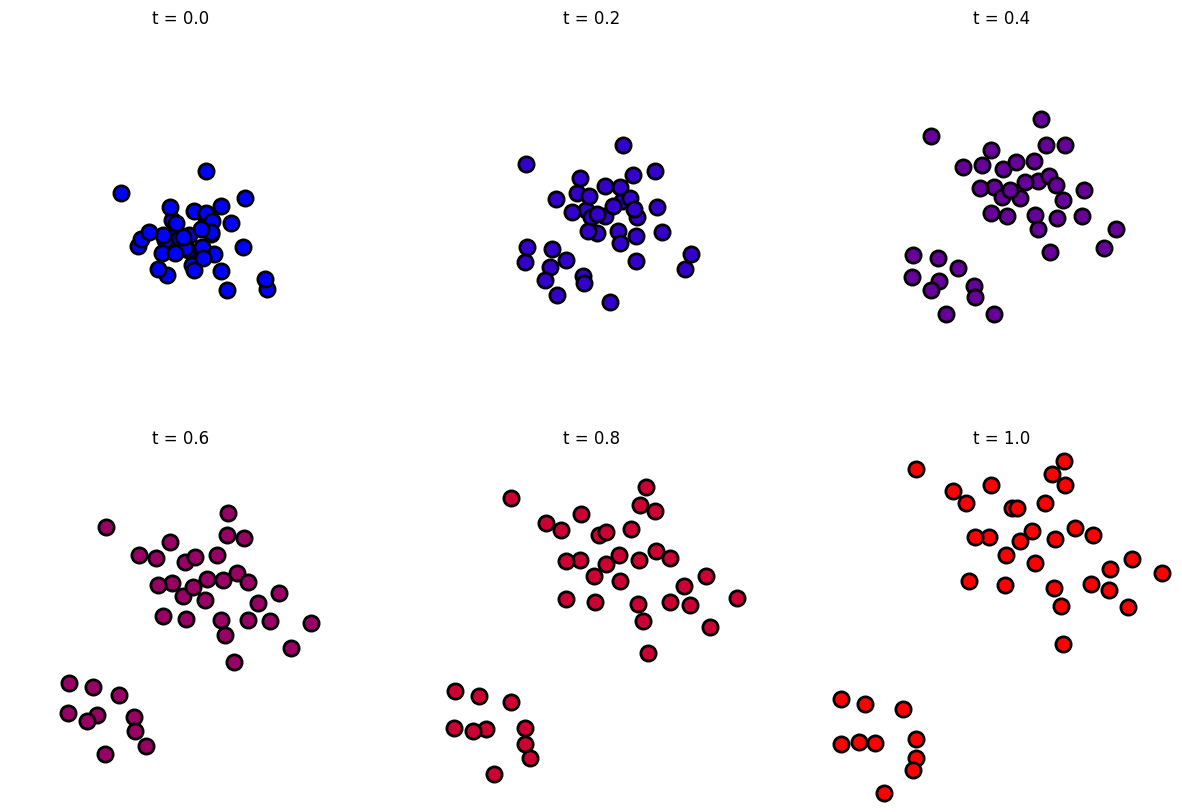

In [55]:
# Exercise 8: Optimal Assignment (n = m = 40, uniform weights)

# Step 1: Set n = m = 40
n8 = m8 = 40

# Step 2: Same point cloud construction as Ex.1
sigma_1 = 0.3
sigma_2 = 0.5
cov_1 = np.array([[sigma_1**2, 0], [0, sigma_1**2]])
cov_2 = np.array([[sigma_2**2, 0], [0, sigma_2**2]])

X8 = np.random.multivariate_normal([0, 0],   cov_1, size=n8).T        # (2, 40)
Y8_1 = np.random.multivariate_normal([0, 1.6],  cov_2, size=n8//2).T  # (2, 20)
Y8_2 = np.random.multivariate_normal([-1, -1],  cov_1, size=n8//4).T  # (2, 10)
Y8_3 = np.random.multivariate_normal([1, 1],    cov_1, size=n8//4).T  # (2, 10)
Y8 = np.hstack([Y8_1, Y8_2, Y8_3])                                    # (2, 40)

# Step 3: Uniform weights
a8 = np.ones(n8) / n8
b8 = np.ones(m8) / m8

# Step 4: Cost matrix
C8 = np.zeros((n8, m8))
for i in range(n8):
    for j in range(m8):
        diff = X8[:, i] - Y8[:, j]
        C8[i, j] = np.dot(diff, diff)

# Step 5: Solve OT with cvxpy
P8 = cp.Variable((n8, m8))
constraints8 = [
    P8 >= 0,
    cp.sum(P8, axis=1, keepdims=True) == a8.reshape((n8, 1)),
    cp.sum(P8, axis=0, keepdims=True).T == b8.reshape((m8, 1))
]
objective8 = cp.Minimize(cp.sum(cp.multiply(P8, C8)))
prob8 = cp.Problem(objective8, constraints8)
prob8.solve()
print(f"Optimal transport cost: {prob8.value:.4f}")

# Check sparsity: for a permutation matrix we expect exactly n non-zero entries
tol = 1e-5
nnz8 = np.sum(np.abs(P8.value) > tol)
print(f"Non-zero entries (tol={tol}): {nnz8}  |  n+m-1 = {n8+m8-1}  |  n = {n8}")

# Step 6: Visualize optimal assignment
I8, J8 = np.nonzero(P8.value > tol)
plt.figure(figsize=(10, 7))
plt.axis('off')
plt.title("Optimal Assignment (n = m = 40, uniform weights)")
for k in range(len(I8)):
    plt.plot([X8[0, I8[k]], Y8[0, J8[k]]],
             [X8[1, I8[k]], Y8[1, J8[k]]], 'k', lw=1.5)
for i in range(n8):
    myplot(X8[0, i], X8[1, i], a8[i] * n8 * 10, 'b')
for j in range(m8):
    myplot(Y8[0, j], Y8[1, j], b8[j] * m8 * 10, 'r')
plt.xlim(np.min(Y8[0, :]) - .1, np.max(Y8[0, :]) + .1)
plt.ylim(np.min(Y8[1, :]) - .1, np.max(Y8[1, :]) + .1)
plt.show()

# Step 7: Displacement interpolation
Pij8 = P8.value[I8, J8]
plt.figure(figsize=(15, 10))
tlist = np.linspace(0, 1, 6)
for idx in range(len(tlist)):
    t = tlist[idx]
    Xt = (1 - t) * X8[:, I8] + t * Y8[:, J8]
    plt.subplot(2, 3, idx + 1)
    plt.axis("off")
    for k in range(len(Pij8)):
        myplot(Xt[0, k], Xt[1, k], Pij8[k] * len(Pij8) * 6, [[t, 0, 1 - t]])
    plt.title("t = %.1f" % t)
    plt.xlim(np.min(Y8[0, :]) - .1, np.max(Y8[0, :]) + .1)
    plt.ylim(np.min(Y8[1, :]) - .1, np.max(Y8[1, :]) + .1)
plt.show()

**Results:** The optimal coupling has exactly **40 non-zero entries** — matching $n$, not $n+m-1 = 79$. This confirms that $P^\star$ is a **permutation matrix** (scaled by $1/n$): each source particle is sent entirely to a unique target, defining a true **transport map** (an optimal assignment / bijection $\sigma^\star$). Visually, every blue point has exactly one black line going to exactly one red point — no splitting.

**Key differences with the $n \neq m$ case (Ex. 1–7):**

| Property | Ex. 1–7: $n=60$, $m=80$, random weights | Ex. 8: $n=m=40$, uniform weights |
|---|---|---|
| Non-zeros in $P^\star$ | $\leq n+m-1 = 139$ | Exactly $n = 40$ |
| Structure of $P^\star$ | General sparse coupling | Permutation matrix (scaled by $1/n$) |
| Transport map? | **No** — mass splits | **Yes** — bijection $\sigma^\star$ |
| Each source sends to | Multiple targets | Exactly one target |
| Each target receives from | Multiple sources | Exactly one source |

**Why permutation matrices arise here:** When $n = m$ and weights are uniform, the transport polytope $U(a,b)$ (scaled by $n$) coincides with the **Birkhoff polytope** of doubly stochastic matrices. By the **Birkhoff–von Neumann theorem**, its extreme points are exactly the permutation matrices. Since the LP always finds a vertex of the feasible set, the solution is necessarily a permutation.

**Why no transport map when $n \neq m$:** With $n < m$ (60 sources, 80 targets), a bijection is impossible by pigeonhole — some sources must split their mass. More generally, when weights are non-uniform or $n \neq m$, the extreme points of $U(a,b)$ are sparse matrices with at most $n+m-1$ non-zeros, not permutations. Exercise 7 illustrates this: many black lines fan out from the same blue source.

**Displacement interpolation:** In Ex. 8 the interpolation shows 40 clean, non-splitting straight-line trajectories (one per source–target pair). In Ex. 1–7 atoms that share a source fan out over time, creating a visible spreading effect at intermediate values of $t$.

**Numerical note:** In Ex. 1–7 the SCS solver (an interior-point method) reported 2335 non-zeros at tolerance $10^{-8}$, far above the theoretical $n+m-1 = 139$. This is because interior-point methods converge to the interior of the optimal face rather than a vertex, leaving many entries small but non-zero. Reducing the tolerance to $10^{-5}$ recovers the expected sparsity.